# Results Visualization Notebook

This notebook runs final ensemble visualizations for report use in `docs/section6.html`.

In [1]:
#Imports
import numpy as np
import pandas as pd
import sys, os, random
from sklearn.metrics import roc_curve

#Script Imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../.."))) #Allow for imports from src
from src.models.model_artifacts import get_artifact_dir
from src.results.model_loading_core import make_shared_split, set_seed
from src.results.ensemble_models import load_final_ensemble_models, run_five_model_calsoft_t025
from src.results.confusion_groups import get_false_negatives, get_false_positives, get_true_positives
from src.results.performance_panel_viz import plot_operating_point_panel, plot_roc_with_perfect_reference
from src.results.threshold_tradeoff_viz import plot_threshold_tradeoff_curve
from src.results.calibration_distribution_viz import plot_calibration_probability_distribution
from src.results.robustness_viz import plot_temporal_robustness_heatmap
from src.results.interpretability_viz import plot_feature_rank_bump_chart, plot_fn_focused_insight_view
from src.results.case_study_cards_viz import plot_case_study_cards

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [2]:
#Rebuild test probabilities from final saved ensemble setup
set_seed(1945)

raw_df = pd.read_csv('/Users/matthewplambeck/Desktop/Convoy Predictor/data/processed/Complete_Convoy_Data.csv')
raw_df = raw_df.drop(columns=['Unnamed: 0']).reset_index(drop=True)

model_df = raw_df.drop(columns=[
    'Convoy Number',
    'Number of Ships Sunk',
    'Depart_Date',
    'Arrival/Dispersal Date',
    'Number of Escorts Sunk',
    'Number of Stragglers Sunk',
    'Total Tons of Ships Sunk',
    'Escort Sink Percentage',
    'Straggler Sink Percentage',])
model_df['Risk'] = (model_df['Overall Sink Percentage'] > 0).astype(int)

X = model_df.drop(columns=['Overall Sink Percentage', 'Risk'])
y = model_df['Risk'].values
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = make_shared_split(X, y, train_size=0.8, random_state=1945)

ARTIFACT_DIR = get_artifact_dir('algorithm_test_3')
loaded = load_final_ensemble_models(
    artifact_dir=ARTIFACT_DIR,
    feature_names=feature_names,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,)

res_calsoft_025, voter_calsoft_025, cm_calsoft_025, rep_calsoft_025 = run_five_model_calsoft_t025(
    X_train,
    X_test,
    y_train,
    y_test,
    loaded['qda'].best_model,
    loaded['ada'].best_model,
    loaded['dt'].best_model,
    loaded['rf'].best_model,
    loaded['et'].best_model,)

y_proba = voter_calsoft_025.predict_proba(X_test)[:, 1]

Ensemble: FiveModel_CalSoft_t0.25
Voting: soft
Threshold: 0.25
ROC AUC: 0.821
Accuracy: 0.830
Recall (class 1): 0.680
Precision (class 1): 0.586
F1 (class 1): 0.630
MCC: 0.522
Balanced Accuracy: 0.775
Confusion Matrix:
        Pred 0  Pred 1
True 0     161      24
True 1      16      34
Classification Report (digits=3):
              precision    recall  f1-score   support

           0      0.910     0.870     0.890       185
           1      0.586     0.680     0.630        50

    accuracy                          0.830       235
   macro avg      0.748     0.775     0.760       235
weighted avg      0.841     0.830     0.834       235



In [3]:
#Load precomputed diagnostic tables from results exports
threshold_sweep_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Threshold_Sweep.xlsx')
segment_metrics_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Segment_Metrics.xlsx')
triangulation_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Feature_Triangulation_Comparison.xlsx')
fn_shap_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Feature_Triangulation_FN_SHAP.xlsx')

In [4]:
#Build confusion-group dataframes for case cards
all_rows_fn, false_negatives = get_false_negatives(voter_calsoft_025, threshold=0.25)
all_rows_fp, false_positives = get_false_positives(voter_calsoft_025, threshold=0.25)
all_rows_tp, true_positives = get_true_positives(voter_calsoft_025, threshold=0.25)

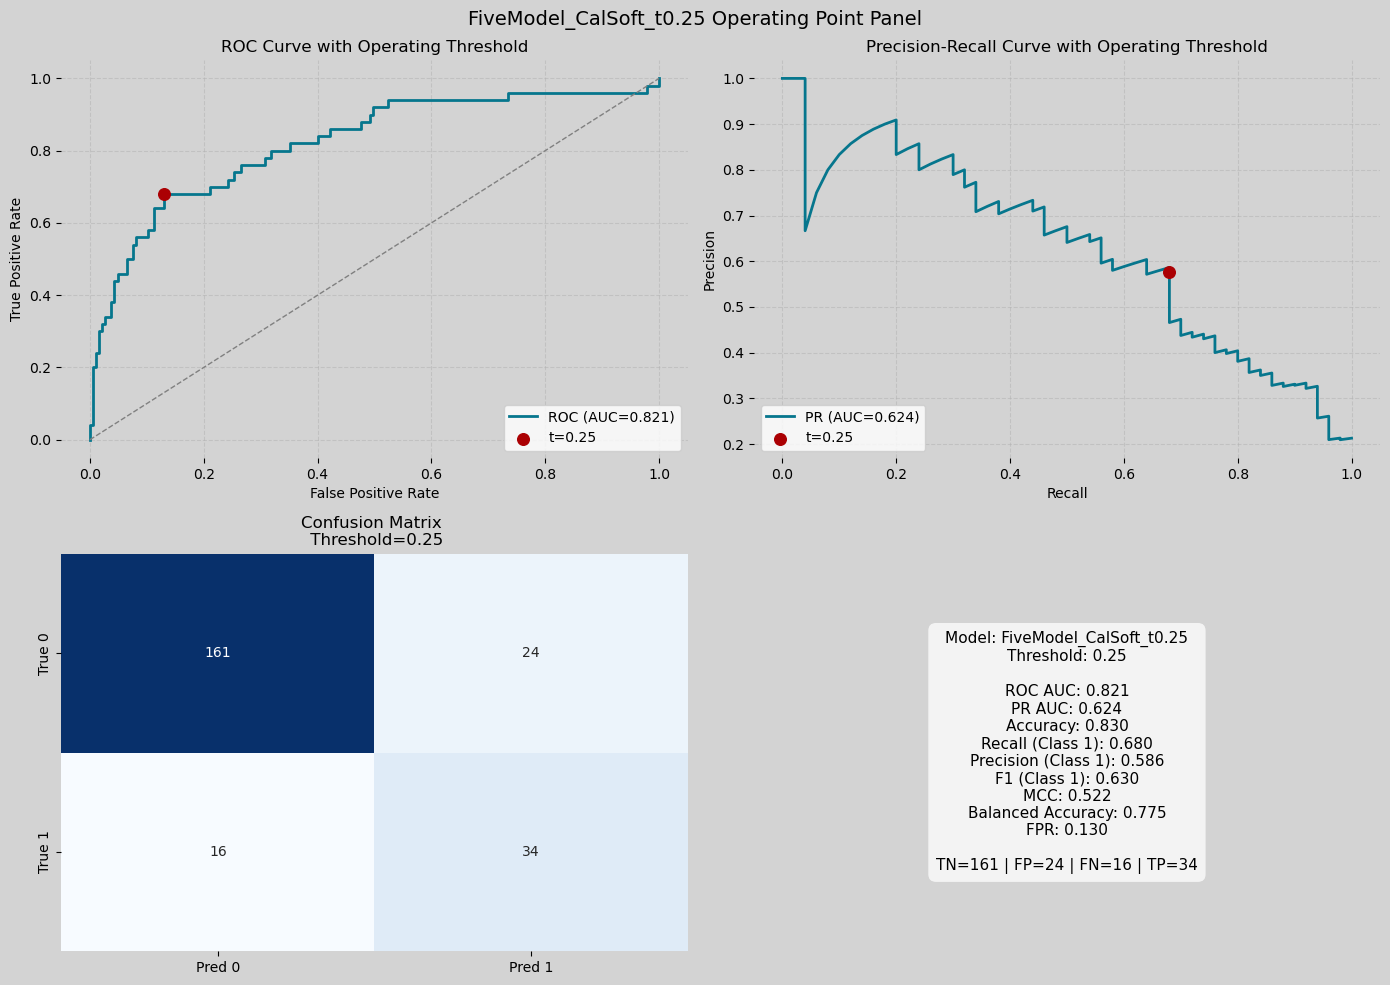

{'roc_auc': 0.8208648648648649,
 'pr_auc': 0.6239853629712846,
 'accuracy': 0.8297872340425532,
 'recall_1': 0.68,
 'precision_1': 0.5862068965517241,
 'f1_1': 0.6296296296296297,
 'mcc': 0.5223315824882198,
 'bal_acc': 0.7751351351351352,
 'fpr': 0.12972972972972974,
 'confusion': {'tn': 161, 'fp': 24, 'fn': 16, 'tp': 34}}

In [5]:
#Operating Point Panel
plot_operating_point_panel(
    y_true=y_test,
    y_proba=y_proba,
    threshold=0.25,
    model_name='FiveModel_CalSoft_t0.25'
)

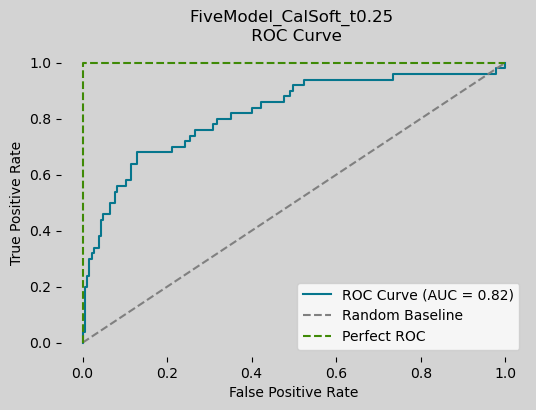

{'roc_auc': 0.8208648648648649}

In [6]:
#ROC Curve with Perfect Reference
plot_roc_with_perfect_reference(
    y_true=y_test,
    y_proba=y_proba,
    model_name='FiveModel_CalSoft_t0.25'
)


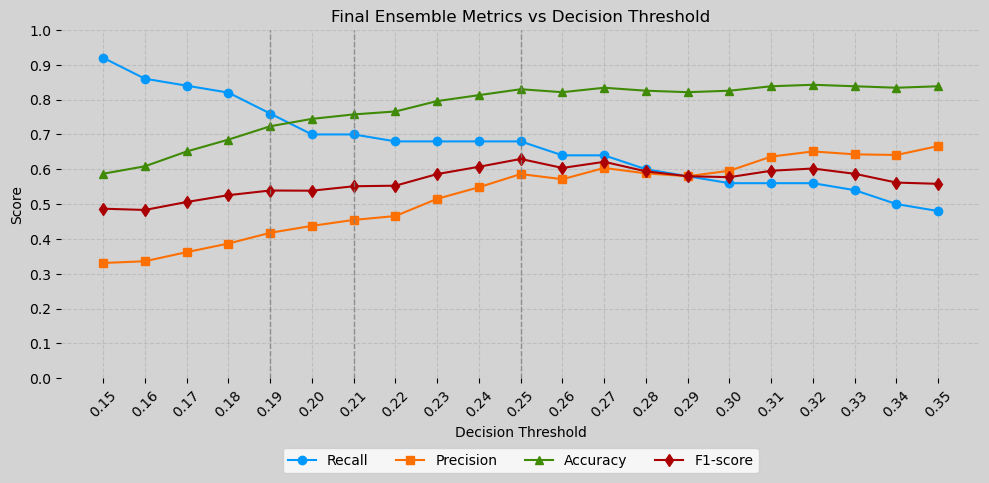

<Axes: title={'center': 'Final Ensemble Metrics vs Decision Threshold'}, xlabel='Decision Threshold', ylabel='Score'>

In [7]:
#Threshold Trade-off Curve
plot_threshold_tradeoff_curve(
    sweep_df=threshold_sweep_df,
    marker_thresholds=(0.25, 0.21, 0.19),
    title='Final Ensemble Metrics vs Decision Threshold',
    model_name='FiveModel_CalSoft_t0.25'
)

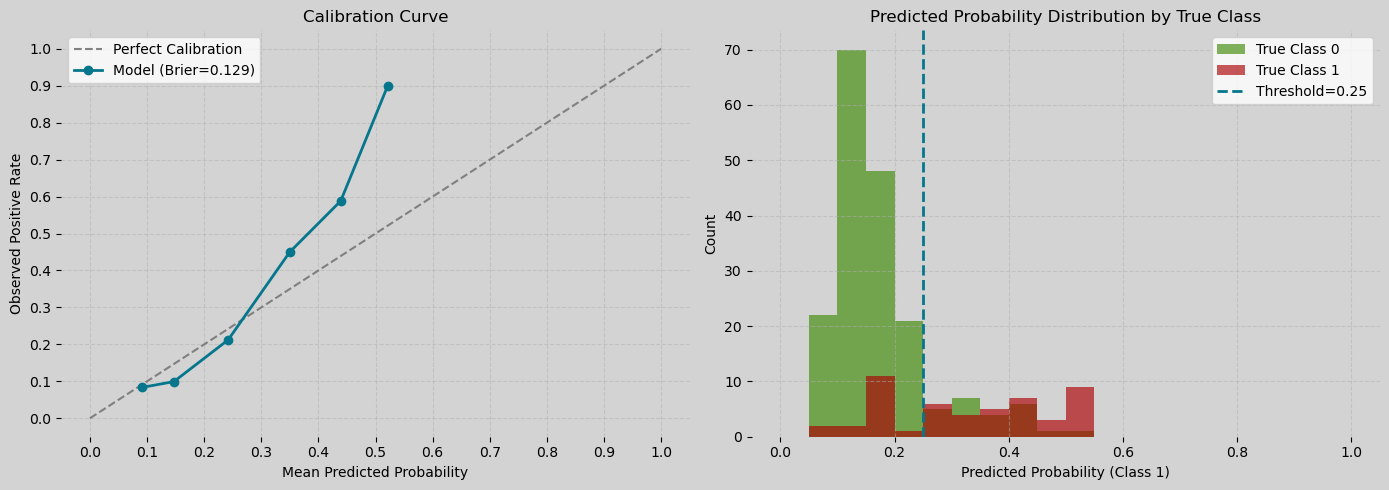

{'brier': 0.12925202310525677,
 'threshold': 0.25,
 'n_class0': 185,
 'n_class1': 50}

In [8]:
#Calibration + Probability Distribution
plot_calibration_probability_distribution(
    y_true=y_test,
    y_proba=y_proba,
    threshold=0.25,
    model_name='FiveModel_CalSoft_t0.25'
)

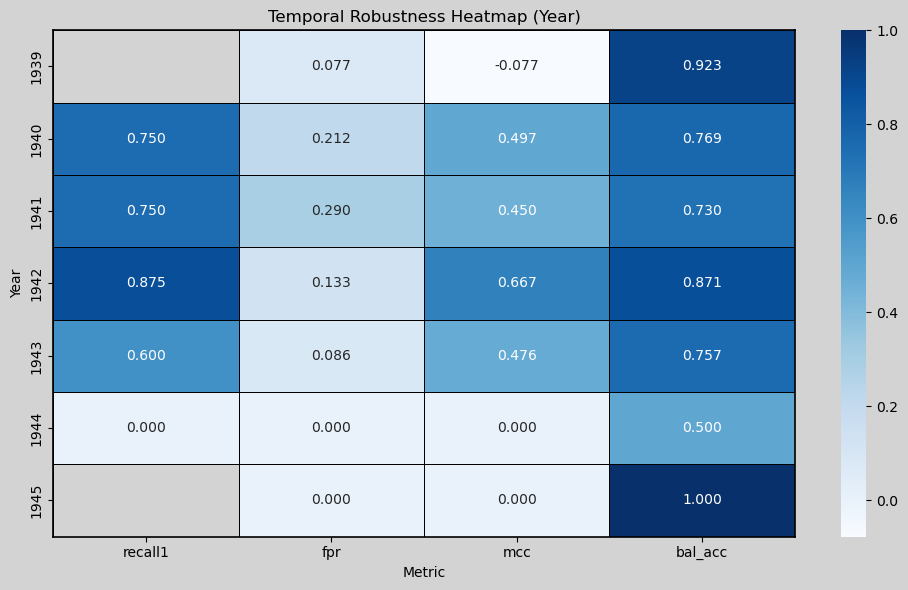

,recall1,fpr,mcc,bal_acc
segment_value,,,,
1939,NaN,0.076923,-0.076923,0.923077
1940,0.750,0.212121,0.496905,0.768939
1941,0.750,0.290323,0.449636,0.729839
1942,0.875,0.133333,0.666709,0.870833
1943,0.600,0.085714,0.476331,0.757143
1944,0.000,0.000000,0.000000,0.500000
1945,NaN,0.000000,0.000000,1.000000


In [9]:
#Temporal Robustness Heatmap
plot_temporal_robustness_heatmap(
    segment_metrics_df=segment_metrics_df,
    segment_type='Year',
    model_name='FiveModel_CalSoft_t0.25'
)

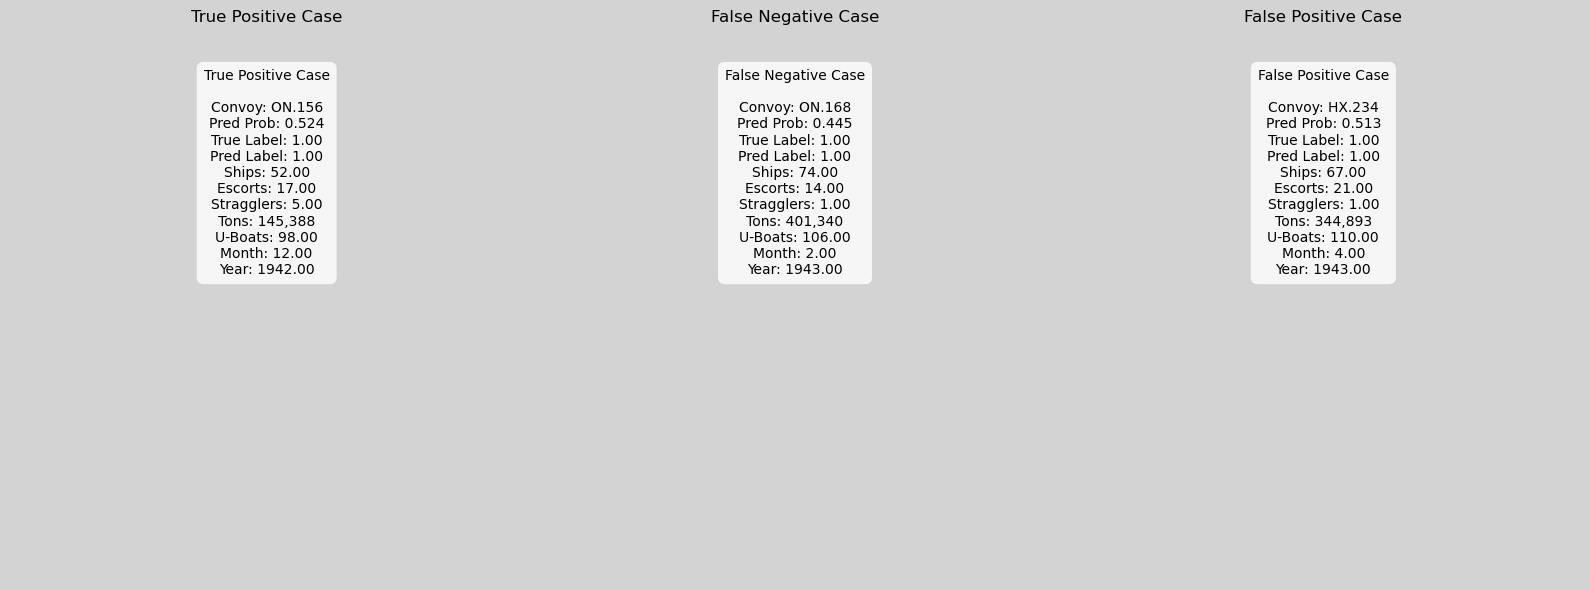

{'tp': {'Convoy Number': 'ON.156',
  'Number of Ships': 52.0,
  'Number of Escort Ships': 17.0,
  'Number of Stragglers': 5.0,
  'Number of Ships Sunk': 1.0,
  'Total Tons of Convoy': 145388.0,
  'Overall Sink Percentage': 1.92307692307692,
  'Avg Number of U-Boats in Atlantic': 98.0,
  'Escort Ratio': 0.326923076923077,
  'Time At Sea (Days)': 24.0,
  'Month': 12.0,
  'Year': 1942.0,
  'Previous Month Avg Sink %': 2.14739043258357,
  'Approx. Sighting Range': 23.9165088416414,
  'At Risk (0/1)': 1.0,
  'Predicted At Risk (0/1)': 1.0,
  'Pred_Prob': 0.5243960091673104,
  'Is_Test': True,
  'Is_True_Positive': True},
 'fn': {'Convoy Number': 'ON.168',
  'Number of Ships': 74.0,
  'Number of Escort Ships': 14.0,
  'Number of Stragglers': 1.0,
  'Number of Ships Sunk': 2.0,
  'Total Tons of Convoy': 401340.0,
  'Overall Sink Percentage': 2.7027027027027,
  'Avg Number of U-Boats in Atlantic': 106.0,
  'Escort Ratio': 0.189189189189189,
  'Time At Sea (Days)': 19.0,
  'Month': 2.0,
  'Year

In [10]:
#Case Study Cards
plot_case_study_cards(
    true_positive_df=true_positives,
    false_negative_df=false_negatives,
    false_positive_df=false_positives,
    model_name='FiveModel_CalSoft_t0.25')

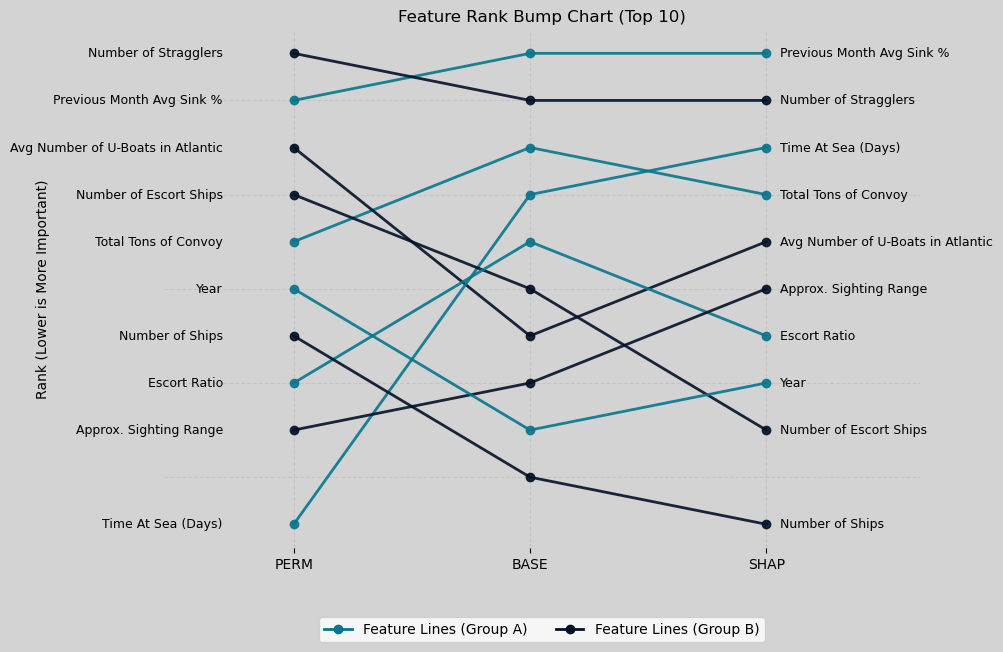

,feature,perm_rank,base_rank,shap_rank
7,Previous Month Avg Sink %,2,1,1
6,Number of Stragglers,1,2,2
9,Total Tons of Convoy,5,3,4
1,Avg Number of U-Boats in Atlantic,3,7,5
8,Time At Sea (Days),11,4,3
4,Number of Escort Ships,4,6,9
2,Escort Ratio,8,5,7
0,Approx. Sighting Range,9,8,6
10,Year,6,9,8
5,Number of Ships,7,10,11


In [11]:
#Bump/Slope Feature Rank Chart
plot_feature_rank_bump_chart(
    triangulation_df=triangulation_df,
    top_k=10,
    model_name='FiveModel_CalSoft_t0.25'
)

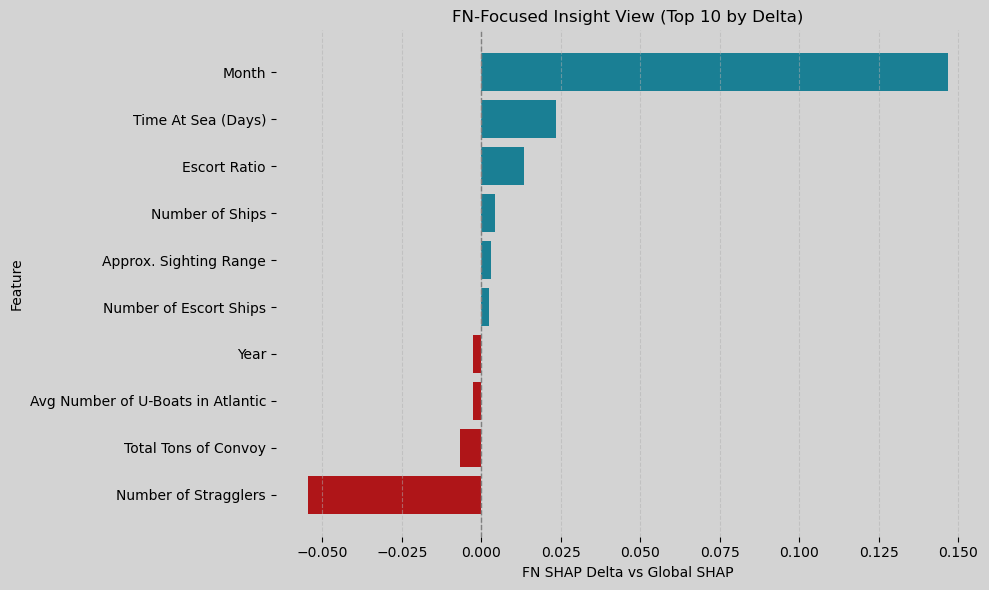

,feature,delta_fn_vs_global
0,Month,0.146821
1,Time At Sea (Days),0.023525
2,Escort Ratio,0.013428
7,Number of Ships,0.004227
5,Approx. Sighting Range,0.003175
8,Number of Escort Ships,0.002294
9,Year,-0.002688
3,Avg Number of U-Boats in Atlantic,-0.002715
4,Total Tons of Convoy,-0.006693
6,Number of Stragglers,-0.054568


In [12]:
#FN-Focused Insight View
plot_fn_focused_insight_view(
    fn_shap_df=fn_shap_df,
    top_k=10,
    model_name='FiveModel_CalSoft_t0.25'
)